In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
%matplotlib inline

df = pd.read_parquet('../data/fe_train_final.parquet')
print(f"Shape: {df.shape}")

Shape: (307511, 202)


In [2]:
target = 'TARGET'
drop_cols = ['SK_ID_CURR', target]

X = df.drop(columns=drop_cols)
y = df[target]

# Drop object columns (LightGBM needs numeric)
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Dropping {len(cat_cols)} object columns: {cat_cols}")
X = X.drop(columns=cat_cols)

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Default rate: {y.mean():.2%}")

Dropping 16 object columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Features: 184, Samples: 307511
Default rate: 8.07%


In [3]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 50,
    'scale_pos_weight': 11,
    'verbosity': -1,
    'n_jobs': -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**params, n_estimators=1000)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
    )

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    auc_scores.append(fold_auc)
    print(f"Fold {fold+1} AUC: {fold_auc:.4f}")

print(f"\nMean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

Training until validation scores don't improve for 50 rounds
[200]	valid_0's auc: 0.773919
Early stopping, best iteration is:
[270]	valid_0's auc: 0.774031
Fold 1 AUC: 0.7740
Training until validation scores don't improve for 50 rounds
[200]	valid_0's auc: 0.778668
Early stopping, best iteration is:
[174]	valid_0's auc: 0.778937
Fold 2 AUC: 0.7789
Training until validation scores don't improve for 50 rounds
[200]	valid_0's auc: 0.770982
Early stopping, best iteration is:
[177]	valid_0's auc: 0.771096
Fold 3 AUC: 0.7711
Training until validation scores don't improve for 50 rounds
[200]	valid_0's auc: 0.77869
Early stopping, best iteration is:
[248]	valid_0's auc: 0.778834
Fold 4 AUC: 0.7788
Training until validation scores don't improve for 50 rounds
[200]	valid_0's auc: 0.77042
Early stopping, best iteration is:
[229]	valid_0's auc: 0.770625
Fold 5 AUC: 0.7706

Mean AUC: 0.7747 ± 0.0036


In [4]:
from sklearn.metrics import confusion_matrix, classification_report

threshold = 0.5
oof_binary = (oof_preds >= threshold).astype(int)

print("=== Confusion Matrix (threshold=0.5) ===")
cm = confusion_matrix(y, oof_binary)
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y, oof_binary))

=== Confusion Matrix (threshold=0.5) ===
[[213202  69484]
 [  8645  16180]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.75      0.85    282686
           1       0.19      0.65      0.29     24825

    accuracy                           0.75    307511
   macro avg       0.57      0.70      0.57    307511
weighted avg       0.90      0.75      0.80    307511



Best threshold: 0.65
Best F1: 0.3245


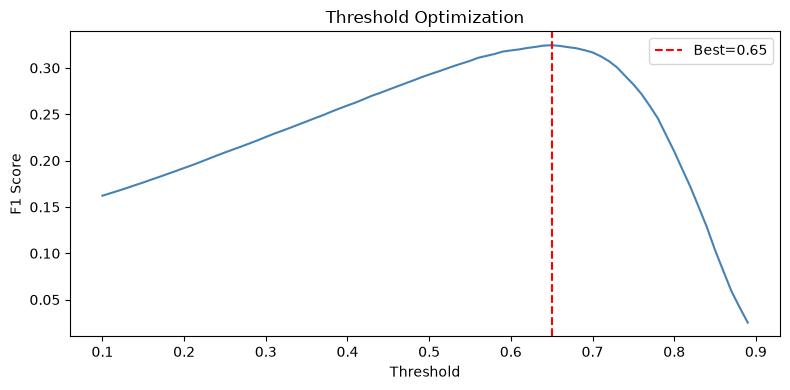

In [5]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

from sklearn.metrics import f1_score

for t in thresholds:
    preds = (oof_preds >= t).astype(int)
    f1_scores.append(f1_score(y, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {best_f1:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Optimization')
plt.legend()
plt.tight_layout()
plt.show()

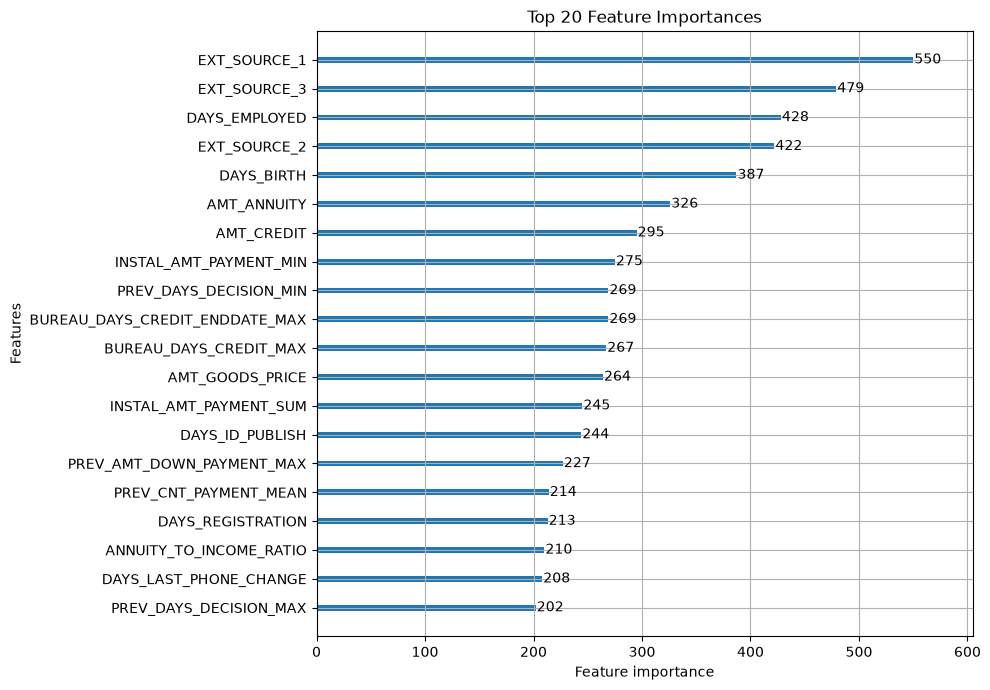

In [6]:
lgb.plot_importance(model, max_num_features=20, figsize=(10, 7), title='Top 20 Feature Importances')
plt.tight_layout()
plt.show()

## Model Results

- **Mean CV AUC: 0.7747 ± 0.0036** (5-fold stratified)
- Best threshold: 0.65 (F1 = 0.3245)
- Top features: EXT_SOURCE_1/2/3, DAYS_EMPLOYED, DAYS_BIRTH
- Early stopping triggered at ~174-270 trees per fold
- Class imbalance handled via scale_pos_weight=11